### Porcentaje de puntos evaluados con reordenaciones EJECUCIÓN VERSIÓN 2

In [1]:
cesga = True

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
import numpy as np
from pathlib import Path


def plot_pruning_points(csv_path: str, save: bool = False) -> None:
    df = pd.read_csv(csv_path)
    dataset_name = Path(csv_path).stem

    # Para cada hoja solo nos quedamos con la clave elegida (mejor poda)
    best = df.loc[df.groupby(['leaf', 'kernel', 'mode', 'radius'])['count'].idxmin()].copy()
    best['pruned'] = best['total'] - best['count']

    # Agregamos por radio y kernel: suma de puntos totales y puntos evaluados
    agg = (
        best.groupby(['mode', 'kernel', 'radius'])
        .agg(total_pts=('total', 'sum'), evaluated_pts=('count', 'sum'))
        .reset_index()
    )
    agg['pct_pruned'] = (1 - agg['evaluated_pts'] / agg['total_pts']) * 100

    modes = agg['mode'].unique()
    kernels = sorted(agg['kernel'].unique())
    radii = sorted(agg['radius'].unique())

    for mode in modes:
        df_mode = agg[agg['mode'] == mode]

        n_kernels = len(kernels)
        n_radii   = len(radii)
        group_width = 0.8
        bar_width   = group_width / (n_radii * 2)   # total + evaluated por radio

        x = np.arange(n_kernels)
        colors_total = plt.cm.Blues(np.linspace(0.4, 0.8, n_radii))
        colors_eval  = plt.cm.Oranges(np.linspace(0.4, 0.8, n_radii))

        fig, ax = plt.subplots(figsize=(max(10, n_kernels * 3), 6))

        for ri, radius in enumerate(radii):
            df_r = df_mode[df_mode['radius'] == radius].set_index('kernel')

            offset_total = (ri * 2 - (n_radii - 1)) * bar_width - bar_width / 2
            offset_eval  = offset_total + bar_width

            totals     = [df_r.loc[k, 'total_pts']     if k in df_r.index else 0 for k in kernels]
            evaluated  = [df_r.loc[k, 'evaluated_pts'] if k in df_r.index else 0 for k in kernels]
            pcts       = [df_r.loc[k, 'pct_pruned']    if k in df_r.index else 0 for k in kernels]

            # Media de L por kernel para este radio
            mean_L_by_kernel = (
                best[best['mode'] == mode][best['radius'] == radius]
                .groupby('kernel')['L']
                .mean()
            )

            bars_t = ax.bar(x + offset_total, totals,    bar_width,
                            label=f'r={radius} total',
                            color=colors_total[ri], edgecolor='white', linewidth=0.5)
            bars_e = ax.bar(x + offset_eval,  evaluated, bar_width,
                            label=f'r={radius} evaluados',
                            color=colors_eval[ri],  edgecolor='white', linewidth=0.5)

            for ki, (bar, pct, k) in enumerate(zip(bars_e, pcts, kernels)):
                if pct > 0:
                    ax.text(bar.get_x() + bar.get_width() / 2,
                            bar.get_height() * 1.01,
                            f'{pct:.1f}%',
                            ha='center', va='bottom', fontsize=7, color='black')

                # Ratio r/L debajo del eje X
                mean_L = mean_L_by_kernel.get(k, None)
                if mean_L and mean_L > 0:
                    ratio = radius / mean_L
                    ax.text(bar.get_x() + bar.get_width() / 2,
                            -ax.get_ylim()[1] * 0.06,   # justo debajo del eje
                            f'R/L={ratio:.2f}',
                            ha='center', va='top', fontsize=6, color='gray',
                            rotation=20)

        ax.set_xticks(x)
        ax.set_xticklabels([k.upper() for k in kernels], fontsize=11)
        ax.tick_params(axis='x', pad=28)
        ax.set_xlabel('Kernel', fontsize=12)
        ax.set_ylabel('Puntos', fontsize=12)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(
            lambda val, _: f'{val/1e6:.1f}M' if val >= 1e6 else f'{val/1e3:.0f}K'))
        ax.set_title(
            f'Puntos totales vs evaluados con poda\n'
            f'Dataset: {dataset_name}   Modo: {mode}',
            fontsize=13, fontweight='bold')
        ax.legend(ncol=n_radii, fontsize=8, loc='upper right')
        ax.grid(axis='y', alpha=0.3)
        ax.spines[['top', 'right']].set_visible(False)
        plt.show()
        if (save):
            out_path = Path(csv_path).parent / f'{dataset_name}_{mode}_pruning_points.png'
            plt.tight_layout()
            plt.savefig(out_path, dpi=150)
            plt.close()
            print(f'Guardado: {out_path}')


# Uso:


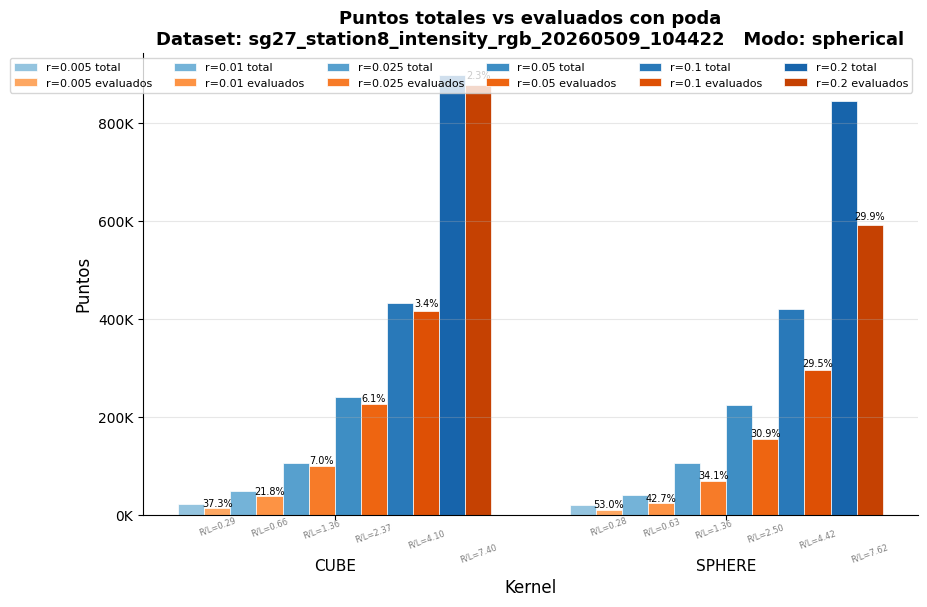

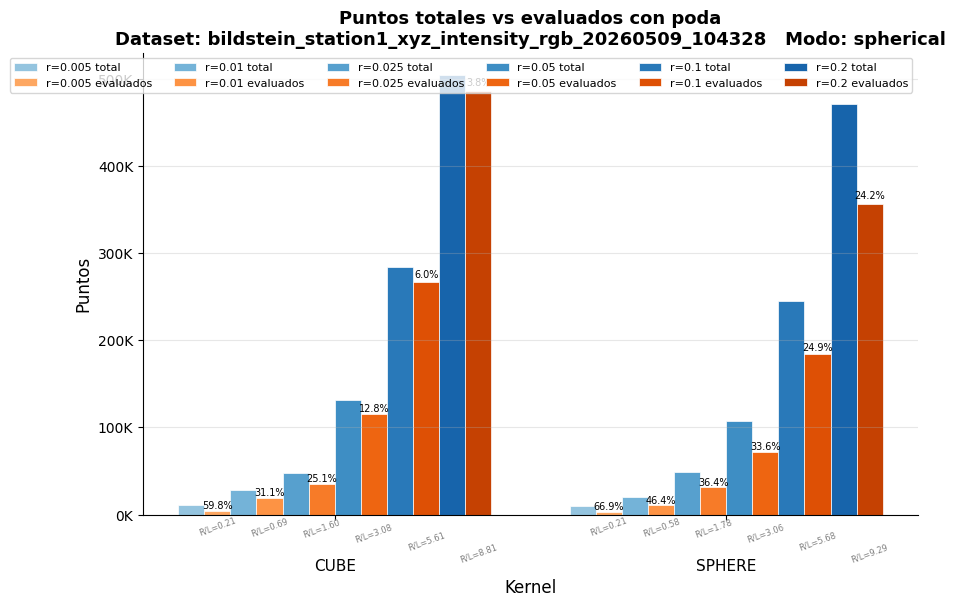

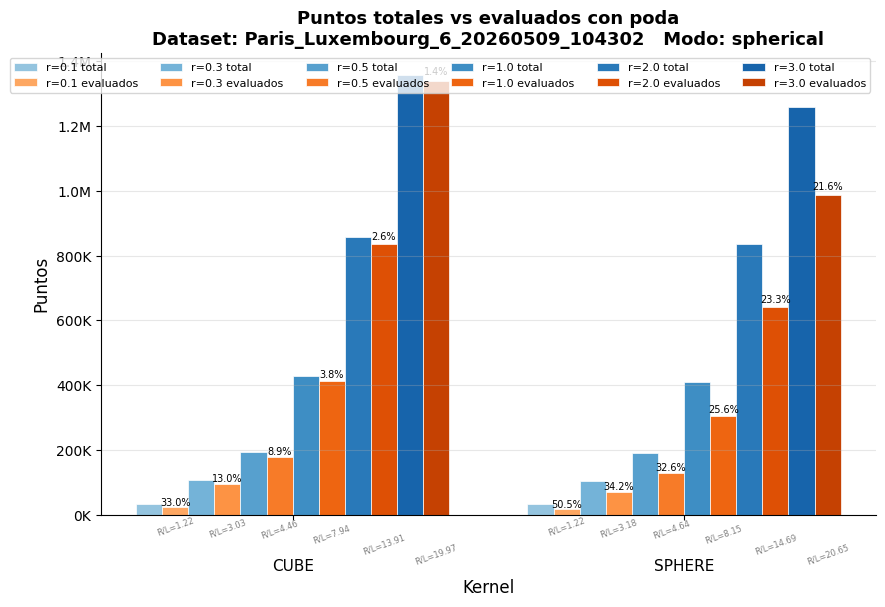

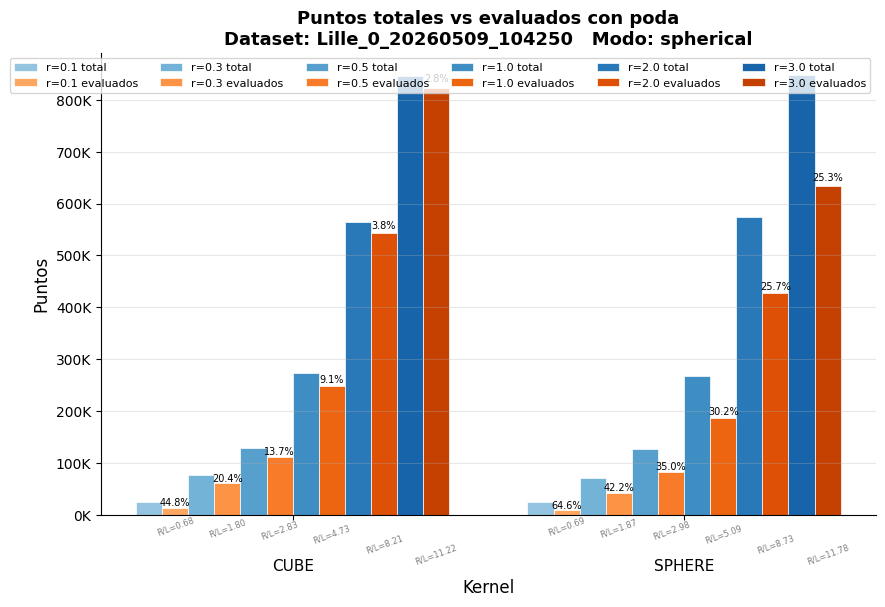

In [3]:
if cesga:
    for log in Path('../outv2.3-ranges').glob('*.log'):
        plot_pruning_points(log, save=False)


### Distribuciones de las podas

In [4]:
def plot_pruning_distribution(csv_path: str, save: bool = False) -> None:
    df = pd.read_csv(csv_path)
    dataset_name = Path(csv_path).stem

    best = df.loc[df.groupby(['leaf', 'kernel', 'mode', 'radius'])['count'].idxmin()].copy()
    best['pct_pruned'] = (1.0 - best['count'] / best['total']) * 100.0

    # Hojas totales por kernel (antes de filtrar pct=0)
    total_leaves_by_kernel = (
        best.groupby(['mode', 'kernel', 'radius'])['leaf']
        .nunique()
        .reset_index()
        .rename(columns={'leaf': 'total_leaves'})
    )

    pruned = best[best['pct_pruned'] > 0.01]

    modes   = pruned['mode'].unique()
    kernels = sorted(pruned['kernel'].unique())
    radii   = sorted(pruned['radius'].unique())

    for mode in modes:
        df_mode  = pruned[pruned['mode'] == mode]
        df_total = total_leaves_by_kernel[total_leaves_by_kernel['mode'] == mode]

        n_kernels = len(kernels)
        fig, axes = plt.subplots(1, n_kernels,
                                  figsize=(7 * n_kernels, 8),
                                  sharey=True)
        if n_kernels == 1:
            axes = [axes]

        colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(radii)))

        for ax, kernel in zip(axes, kernels):
            df_k      = df_mode[df_mode['kernel'] == kernel]
            df_tot_k  = df_total[df_total['kernel'] == kernel].set_index('radius')

            data   = []
            labels = []

            for r in radii:
                d = df_k[df_k['radius'] == r]['pct_pruned'].values
                data.append(d)

                total_l  = df_tot_k.loc[r, 'total_leaves'] if r in df_tot_k.index else 0
                pruned_l = len(d)
                pct_l    = pruned_l / total_l * 100 if total_l > 0 else 0

                labels.append(
                    f'r={r}\n'
                    f'{pruned_l}/{total_l}\n'
                    f'({pct_l:.1f}% hojas)'
                )

            bp = ax.boxplot(data,
                            patch_artist=True,
                            medianprops=dict(color='white', linewidth=2),
                            whiskerprops=dict(linewidth=1.2),
                            capprops=dict(linewidth=1.2),
                            flierprops=dict(marker='o', markersize=2,
                                            alpha=0.3, linestyle='none'))

            for patch, color in zip(bp['boxes'], colors):
                patch.set_facecolor(color)

            for i, d in enumerate(data, start=1):
                if len(d) == 0:
                    continue
                median = np.median(d)
                mean   = np.mean(d)
                ax.text(i, median + 1, f'{median:.1f}%',
                        ha='center', va='bottom', fontsize=7,
                        color='white', fontweight='bold')
                ax.scatter(i, mean, marker='D', color='red',
                           s=20, zorder=5, label='media' if i == 1 else '')

            ax.set_xticks(range(1, len(radii) + 1))
            ax.set_xticklabels(labels, fontsize=8)
            ax.set_xlabel('Radio de búsqueda', fontsize=10)
            ax.set_title(kernel.upper(), fontsize=12, fontweight='bold')
            ax.grid(axis='y', alpha=0.3)
            ax.spines[['top', 'right']].set_visible(False)
            ax.set_ylim(0, 105)

            if ax == axes[0]:
                ax.set_ylabel('% Puntos podados', fontsize=11)
                ax.legend(fontsize=8)

        fig.suptitle(
            f'Distribución del % de poda por hoja\n'
            f'Dataset: {dataset_name}   Modo: {mode}',
            fontsize=13, fontweight='bold', y=1.02)
        plt.show()
        if (save):
            out_path = Path(csv_path).parent / f'{dataset_name}_{mode}_pruning_distribution.png'
            plt.tight_layout()
            plt.savefig(out_path, dpi=150, bbox_inches='tight')
            plt.close()
            print(f'Guardado: {out_path}')

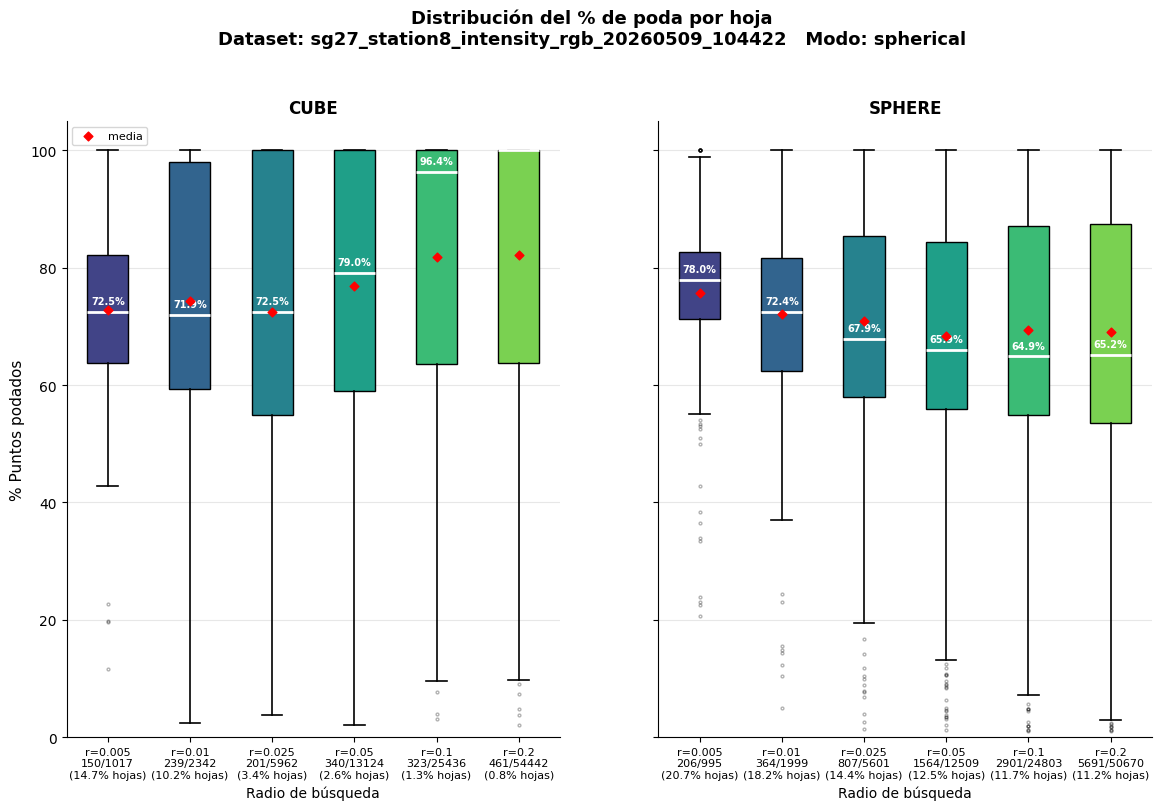

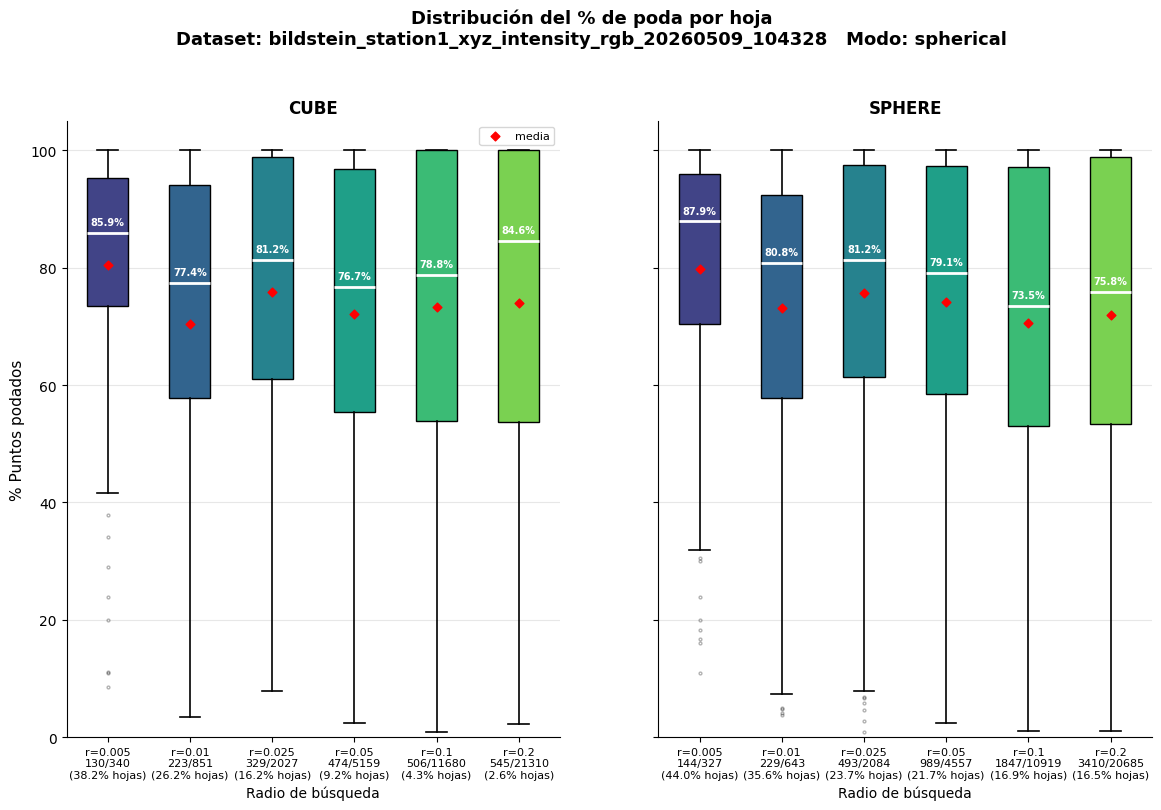

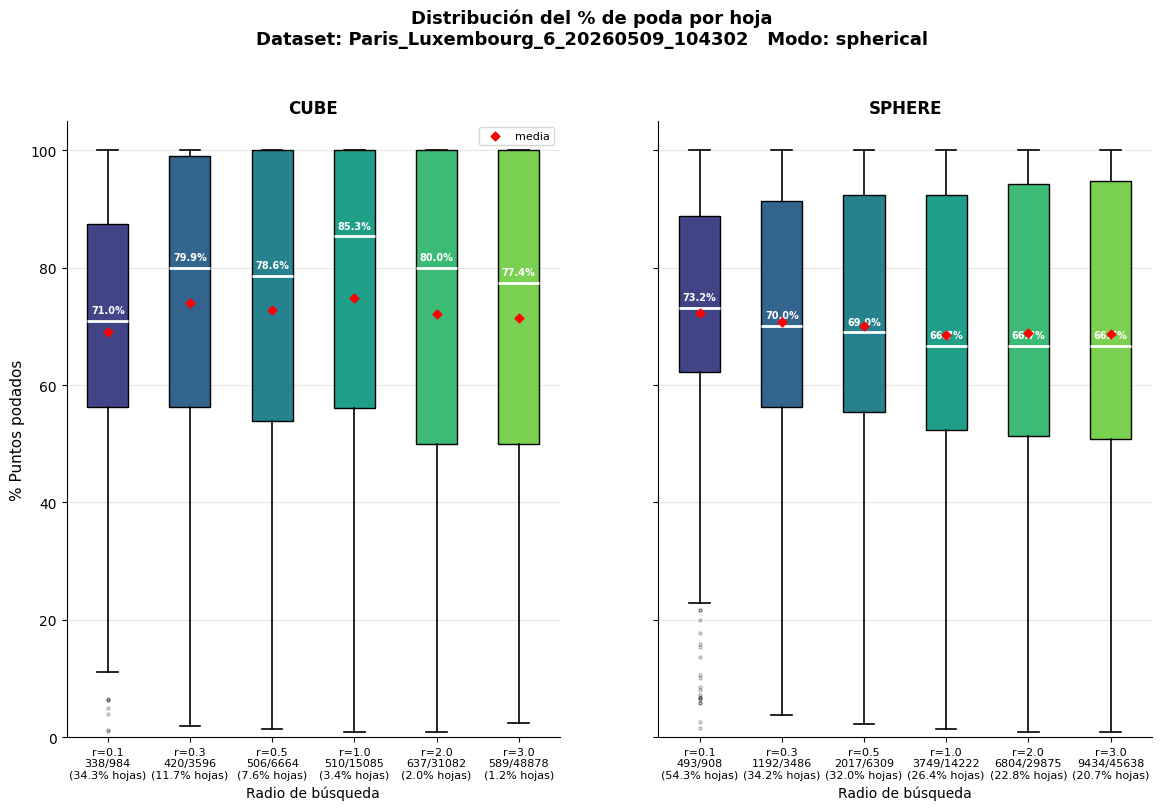

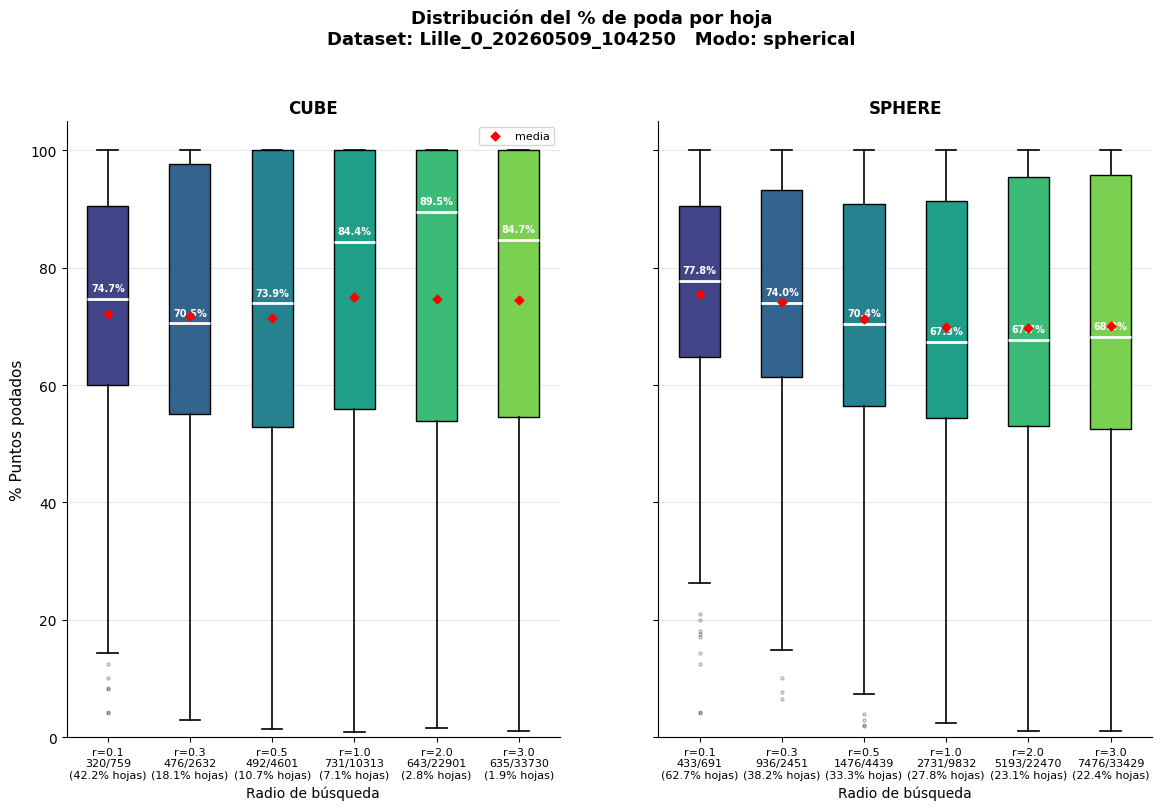

In [5]:
if cesga:
    for log in Path('../outv2.3-ranges').glob('*.log'):
        plot_pruning_distribution(log, save=False)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

def plot_density_analysis(csv_path, save: bool = False) -> None:
    df = pd.read_csv(csv_path)
    dataset_name = Path(csv_path).stem
    
    # 1. Calcular el % de poda
    df['pruning_pct'] = (1 - df['count'] / df['total']) * 100
    
    # 2. Definir rangos de densidad
    bins = [0, 1, 16, 32, 64, 128, 256, 512, 1024, 10000]
    labels = ['0-1', '2-16', '17-32', '33-64', '65-128', '129-256', '257-512', '513-1024', '>1024']
    df['density_range'] = pd.cut(df['total'], bins=bins, labels=labels)
    
    kernels = sorted(df['kernel'].unique())
    n_kernels = len(kernels)
    
    # 3. Setup de la figura
    fig, axes = plt.subplots(1, n_kernels, figsize=(12 * n_kernels, 8), sharey=True)
    if n_kernels == 1: axes = [axes]

    # Paleta de colores para los radios
    radii = sorted(df['radius'].unique())
    modes = sorted(df['mode'].unique())
    palette = sns.color_palette("rocket", n_colors=len(radii))

    for i, kernel in enumerate(kernels):
        ax1 = axes[i]
        df_k = df[df['kernel'] == kernel]
        
        # --- FONDO: Distribución general de hojas (Histograma) ---
        # Sumamos todas las hojas de todos los radios para ver la estructura del dataset
        summary_bg = df_k.groupby('density_range', observed=True)['leaf'].count().reset_index()
        sns.barplot(data=summary_bg, x='density_range', y='leaf', 
                    color='lightgray', alpha=0.3, ax=ax1, label='Densidad Dataset')
        
        ax1.set_title(f'Kernel: {kernel.upper()}', fontsize=18, fontweight='bold', pad=25)
        ax1.set_ylabel('Nº de Hojas (Total)', fontsize=14, color='gray')
        ax1.tick_params(axis='x', rotation=45)
        
        # --- SEGUNDO EJE: Series de Poda por Radio ---
        ax2 = ax1.twinx()
        
        for r_idx, r in enumerate(radii):
            df_r = df_k[df_k['radius'] == r]
            # Calculamos la poda media por cada rango de densidad para este radio concreto
            summary_r = df_r.groupby('density_range', observed=True)['pruning_pct'].mean().reset_index()
            
            # Dibujamos la serie
            sns.lineplot(data=summary_r, x='density_range', y='pruning_pct', 
                         ax=ax2, marker='o', markersize=8, linewidth=2.5,
                         label=f'r = {r}', color=palette[r_idx])

        ax2.set_ylabel('Poda Media (%)', fontsize=14, fontweight='bold')
        ax2.set_ylim(-5, 105)
        
        # Estética pro
        ax1.grid(True, axis='y', linestyle='--', alpha=0.2)
        ax2.legend(title="Radio de Búsqueda", loc='upper left', frameon=True, shadow=True)

    plt.suptitle(f'Evolución de la Eficiencia: Densidad vs. Poda por Radio\nDataset: {dataset_name}', 
                 fontsize=22, fontweight='bold', y=1.05)
    
    plt.tight_layout()
    if save:
        plt.savefig(f"{dataset_name}_pro_density_analysis.png", dpi=200, bbox_inches='tight')
    plt.show()


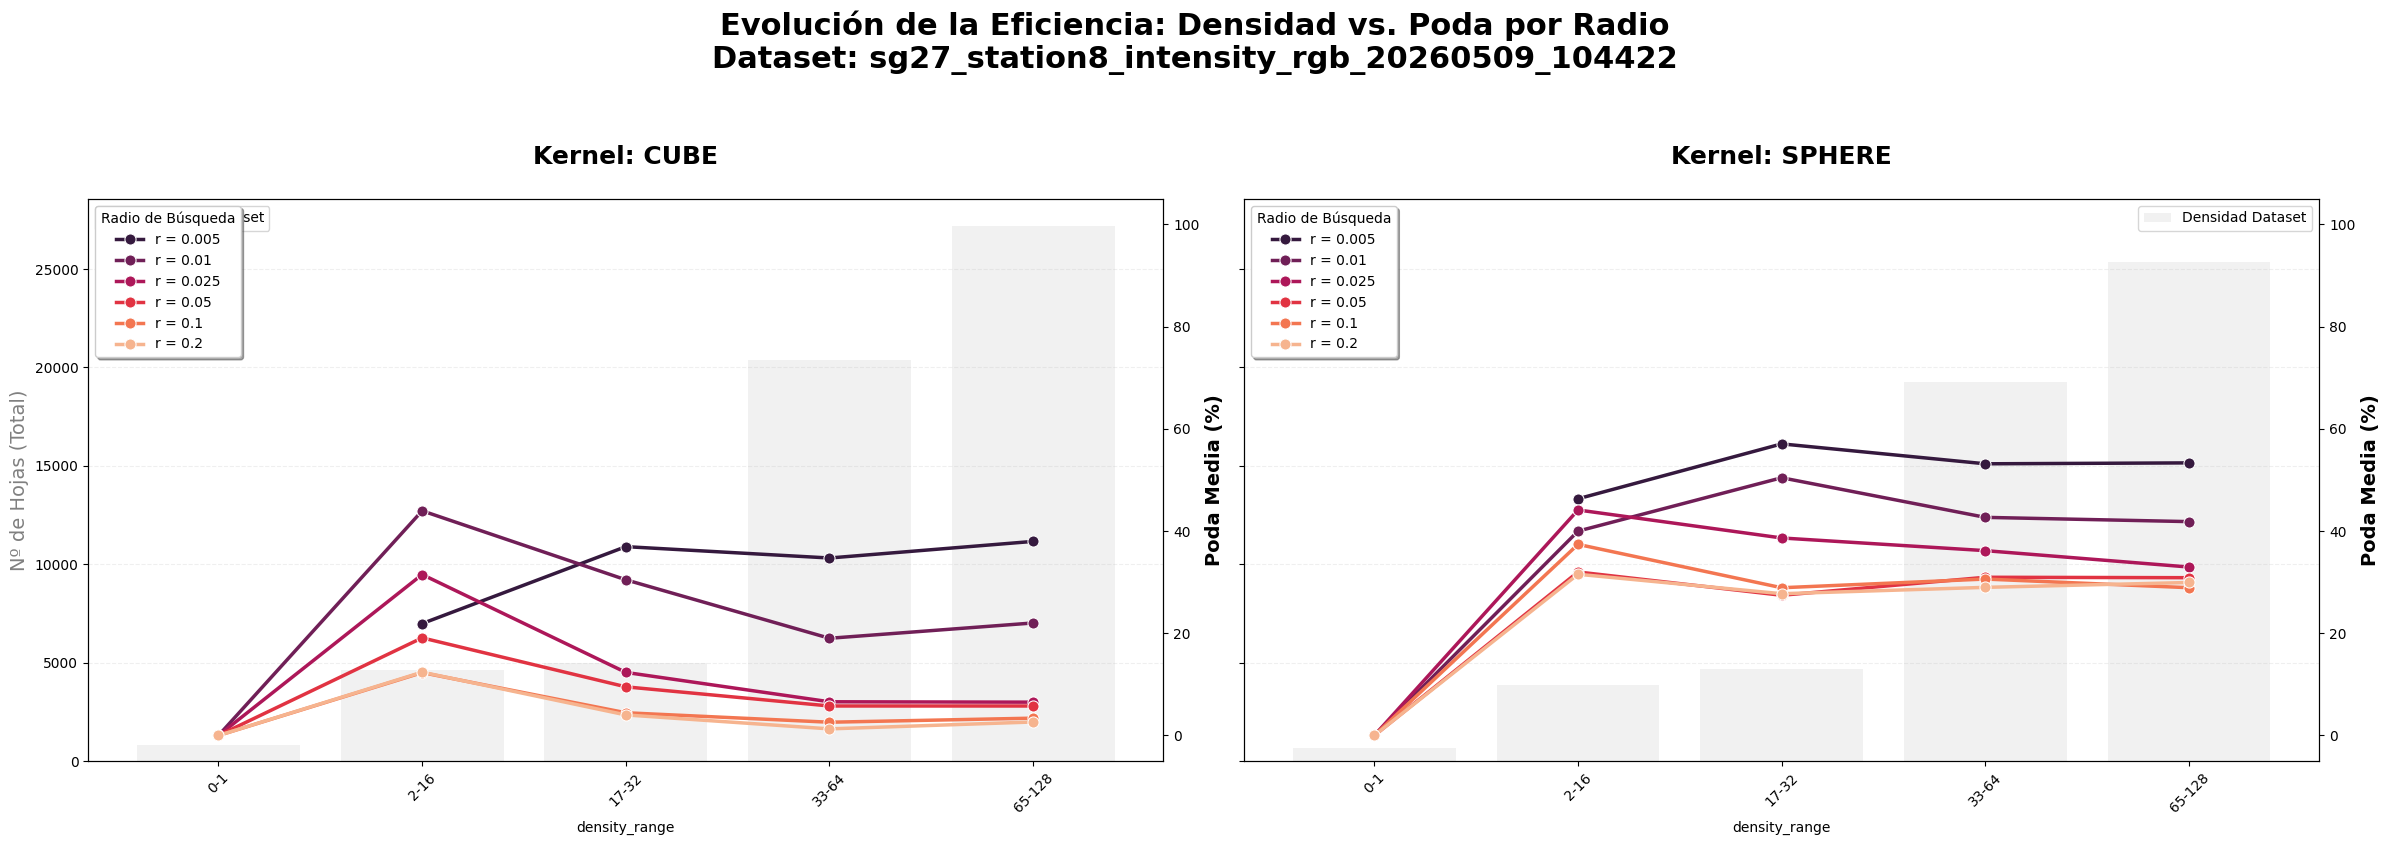

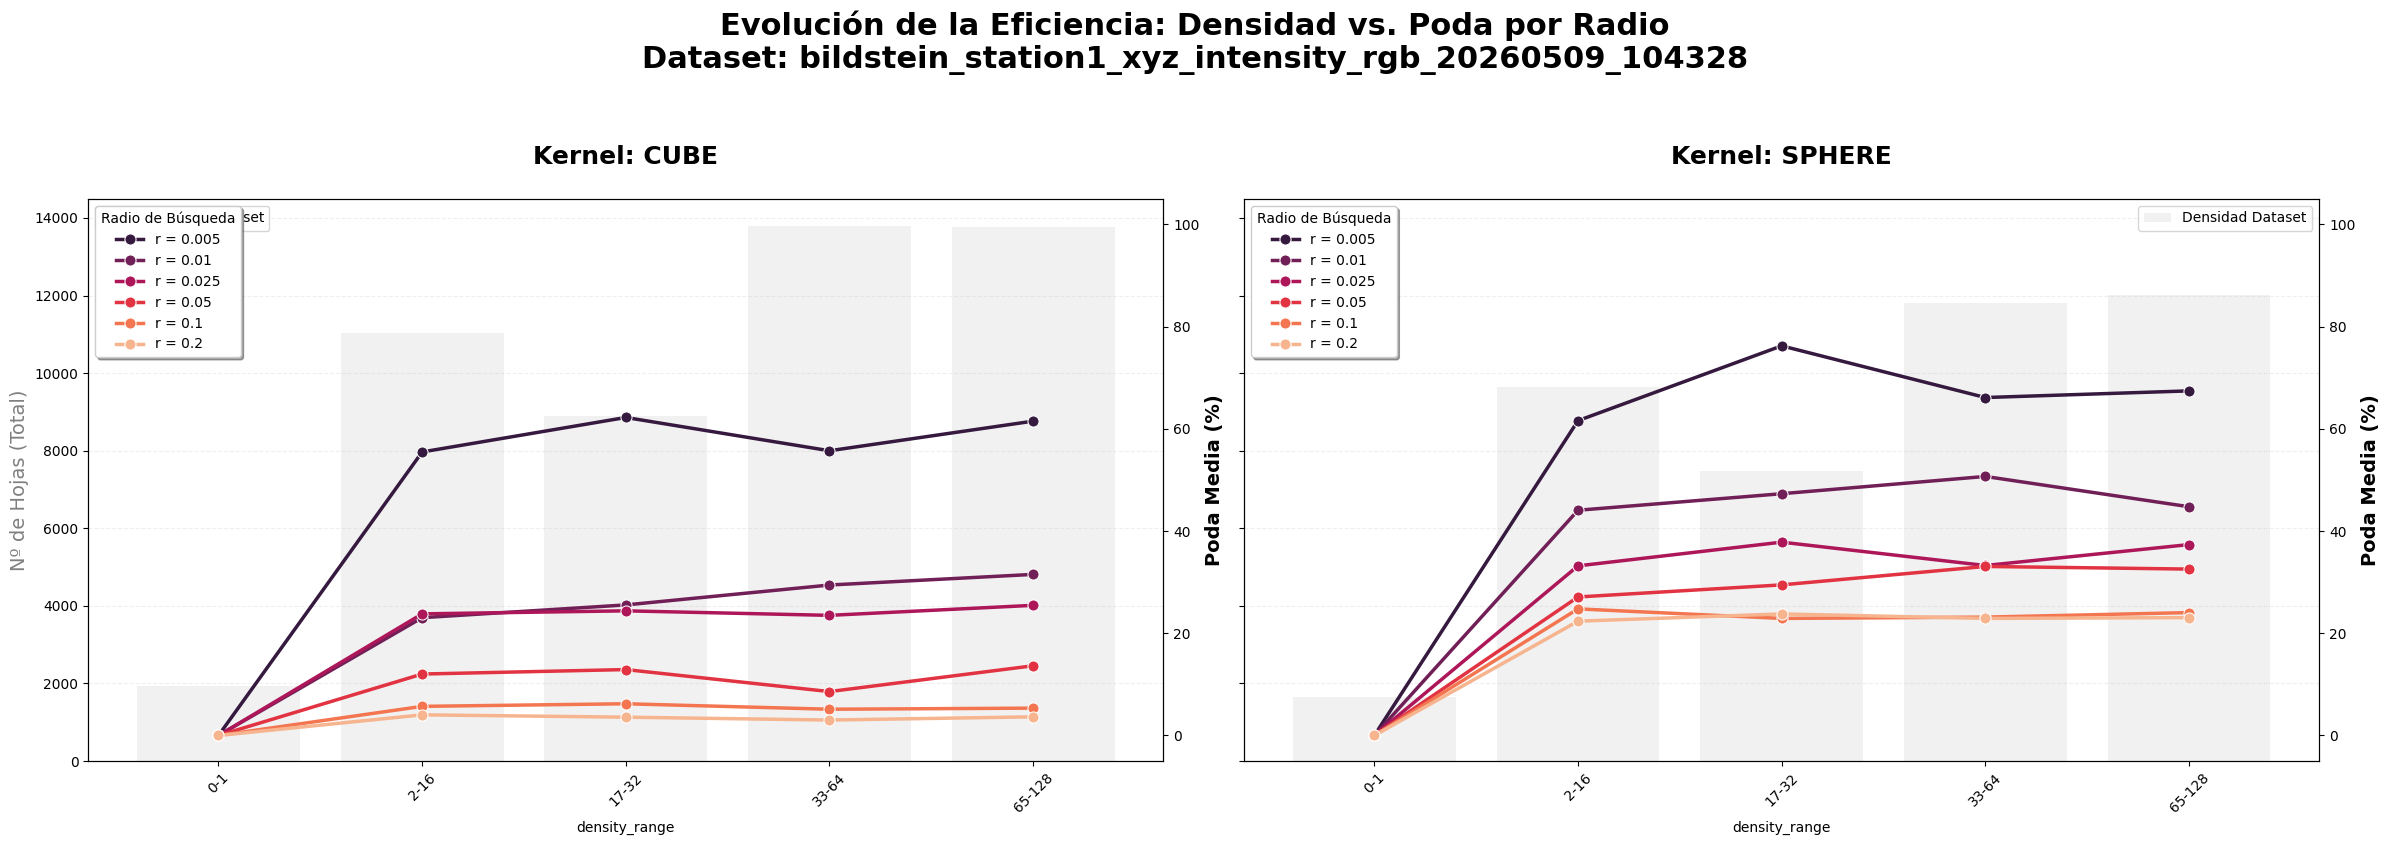

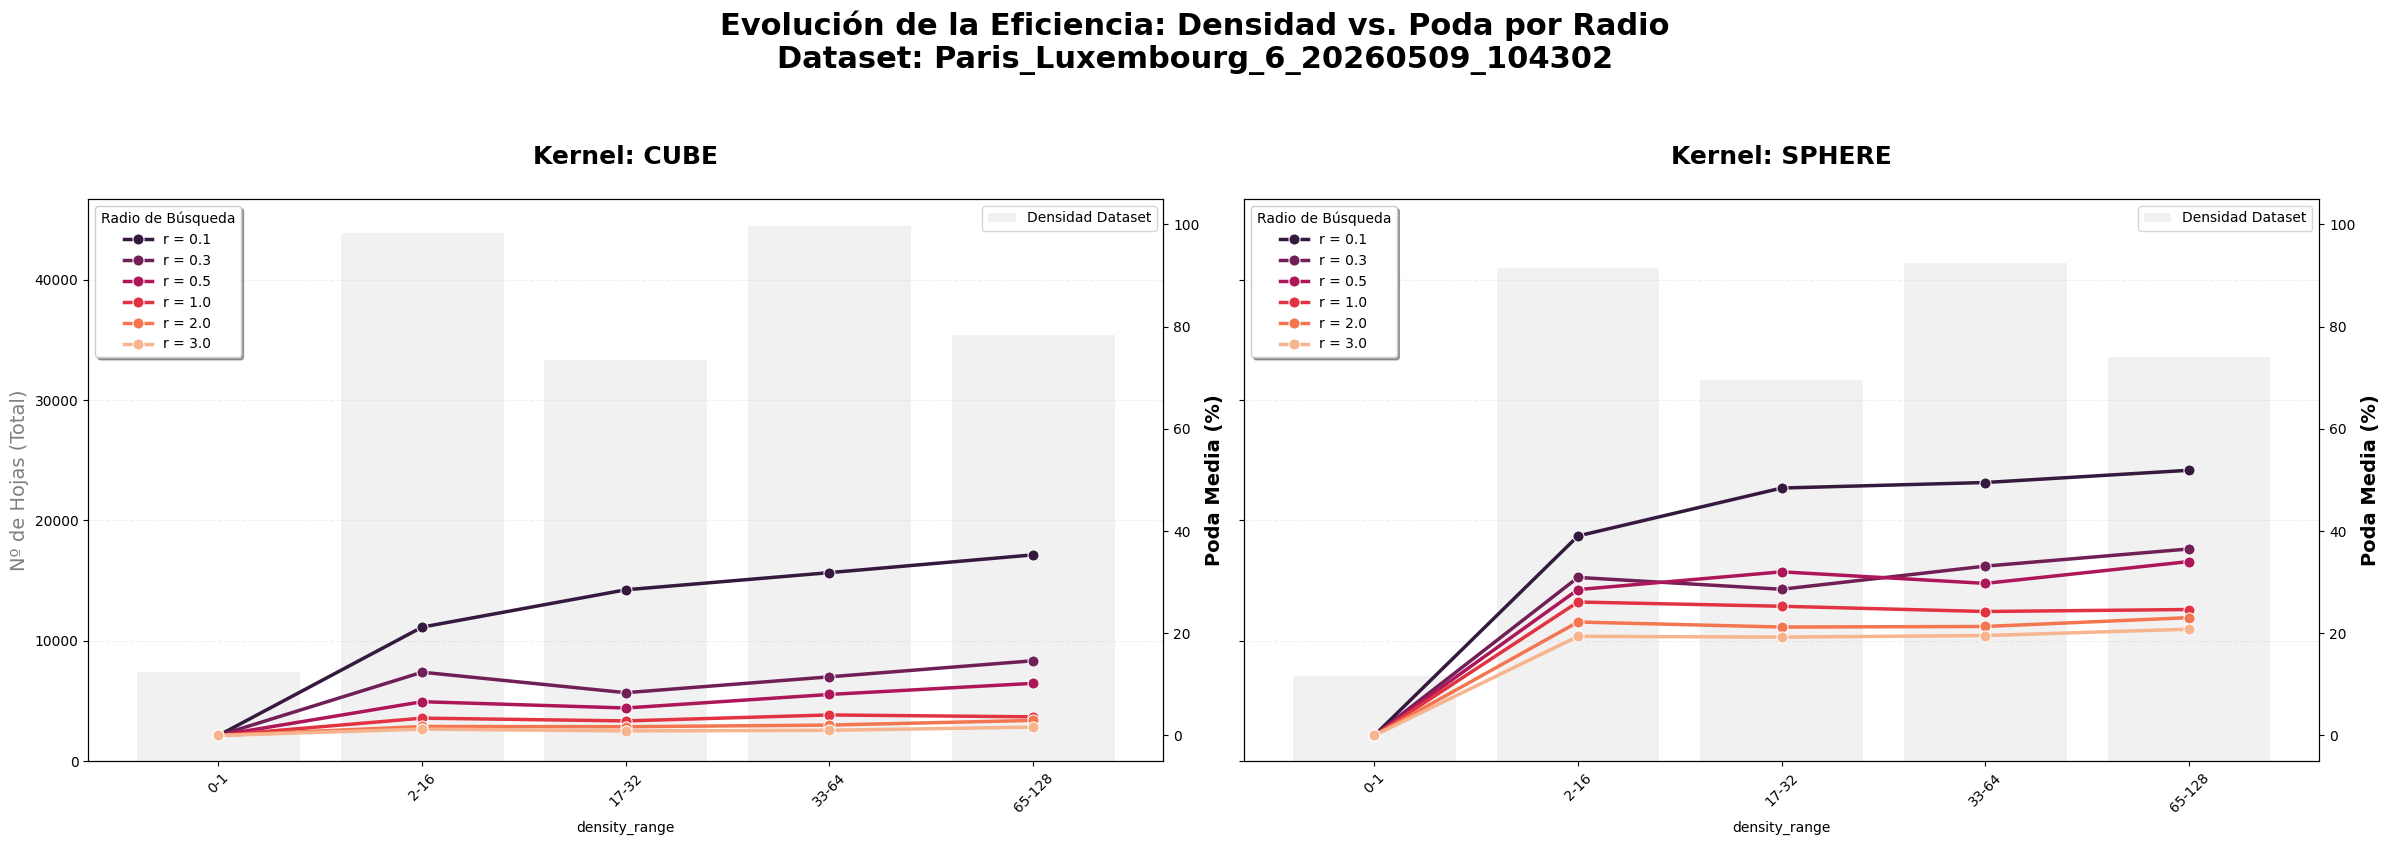

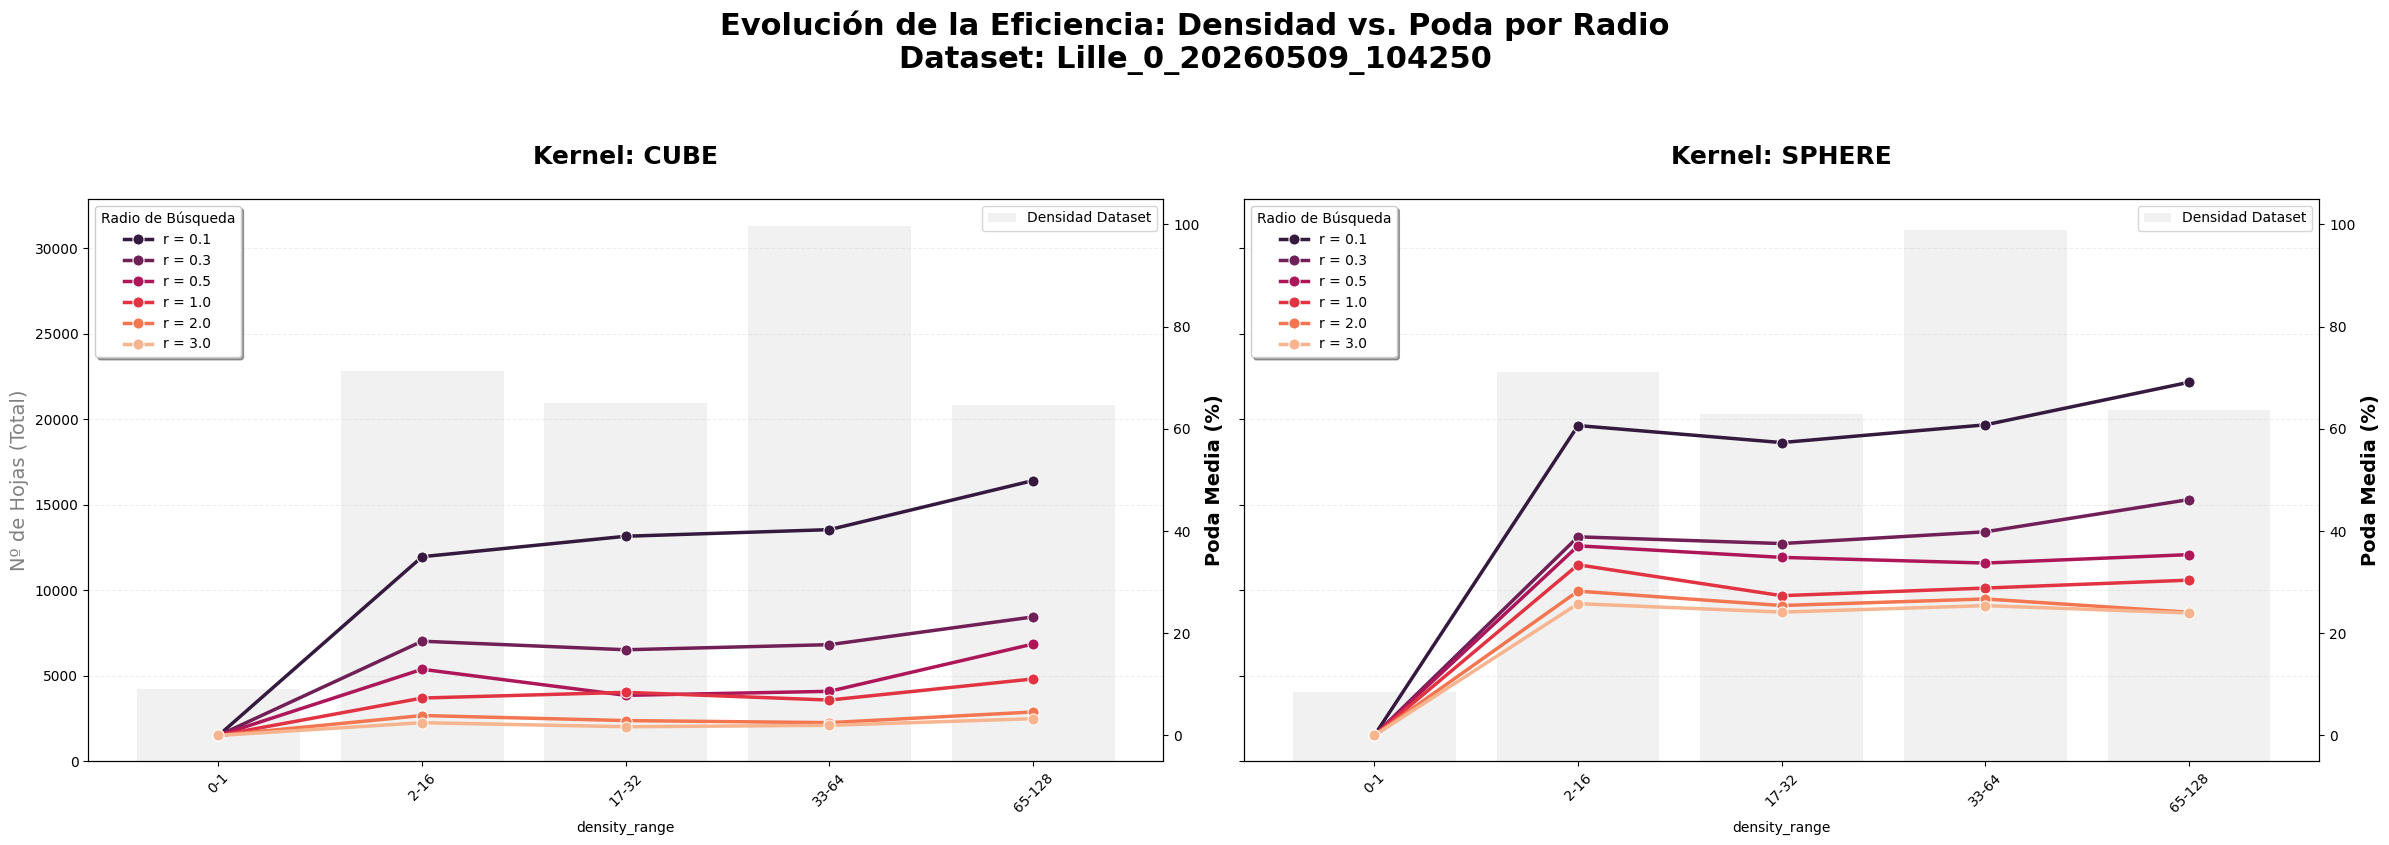

In [7]:
if cesga:
    for log in Path('../outv2.3-ranges').glob('*.log'):
        plot_density_analysis(log)

## Visualización tiempo empleado en selector de rangos vs evaluación puntos

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
def analyze_speedup_and_timing(csv_path: str, save: bool = False, filename: str = ""):
    df = pd.read_csv(csv_path)
    if not filename:
        filename = Path(csv_path).stem
    
    avg_times = df.groupby(['kernel', 'radius', 'mode'])[['get_range_time', 'loop_time']].mean().reset_index()
    
    # Calcular Speedup por búsqueda individual
    reference = df[df['mode'] == 'none'].groupby(['kernel', 'radius'])['loop_time'].mean().reset_index()
    reference.rename(columns={'loop_time': 'loop_time_none'}, inplace=True)
    
    df_speedup = pd.merge(df, reference, on=['kernel', 'radius'])
    
    df_speedup['total_time'] = df_speedup['get_range_time'] + df_speedup['loop_time']
    
    df_speedup['speedup'] = df_speedup['loop_time_none'] / df_speedup['total_time']
    
    df_speedup_filtered = df_speedup[df_speedup['mode'] != 'none']

    # --- GRÁFICA 1: TIEMPO DESGLOSADO (Barras Apiladas) ---
    kernels = avg_times['kernel'].unique()
    for kern in kernels:
        df_kern = avg_times[avg_times['kernel'] == kern]
        
        modes = df_kern['mode'].unique()
        radii = sorted(df_kern['radius'].unique())
        
        fig, ax = plt.subplots(figsize=(12, 7))
        
        width = 0.25  # ancho de las barras
        multiplier = 0
        
        for mode in modes:
            df_m = df_kern[df_kern['mode'] == mode]
            # Asegurar orden de radios
            df_m = df_m.set_index('radius').reindex(radii).reset_index()
            
            offset = width * multiplier
            
            # Parte inferior: get_range_time
            p1 = ax.bar(np.arange(len(radii)) + offset, df_m['get_range_time'], width, 
                        label=f'{mode} (Selector)', alpha=0.6)
            
            # Parte superior: loop_time
            p2 = ax.bar(np.arange(len(radii)) + offset, df_m['loop_time'], width, 
                        bottom=df_m['get_range_time'], label=f'{mode} (Loop)', alpha=0.9)
            
            multiplier += 1

        ax.set_ylabel('Tiempo Medio (Nanosegundos)')
        ax.set_title(f'Desglose de Tiempo: Selector vs Loop\nKernel: {kern.upper()} | Dataset: {filename}')
        ax.set_xticks(np.arange(len(radii)) + width, [f'r={r}' for r in radii])
        ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
        ax.grid(axis='y', alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        if save:
            out_path = Path(csv_path).parent / f'{filename}_{kern}_time_breakdown.png'
            plt.savefig(out_path, dpi=150, bbox_inches='tight')
            plt.close()
            print(f'Guardado: {out_path}')

    # --- GRÁFICA 2: DISTRIBUCIÓN DEL SPEEDUP (Boxplot) ---
    for kern in kernels:
        df_kern_s = df_speedup_filtered[df_speedup_filtered['kernel'] == kern]
        
        plt.figure(figsize=(12, 7))
        sns.boxplot(data=df_kern_s, x='radius', y='speedup', hue='mode', palette='Set2')
        
        plt.axhline(y=1, color='red', linestyle='--', label='Break-even (Speedup=1)')
        
        plt.yscale('log')
        plt.title(f'Distribución de Speedup Individual por Radio\nKernel: {kern.upper()} | Dataset: {filename}')
        plt.ylabel('Speedup (Log Scale)')
        plt.xlabel('Radio de búsqueda')
        plt.legend()
        plt.grid(axis='y', alpha=0.3)
        
        plt.show()
        if save:
            out_path = Path(csv_path).parent / f'{filename}_{kern}_speedup_distribution.png'
            plt.savefig(out_path, dpi=150, bbox_inches='tight')
            plt.close()
            print(f'Guardado: {out_path}')


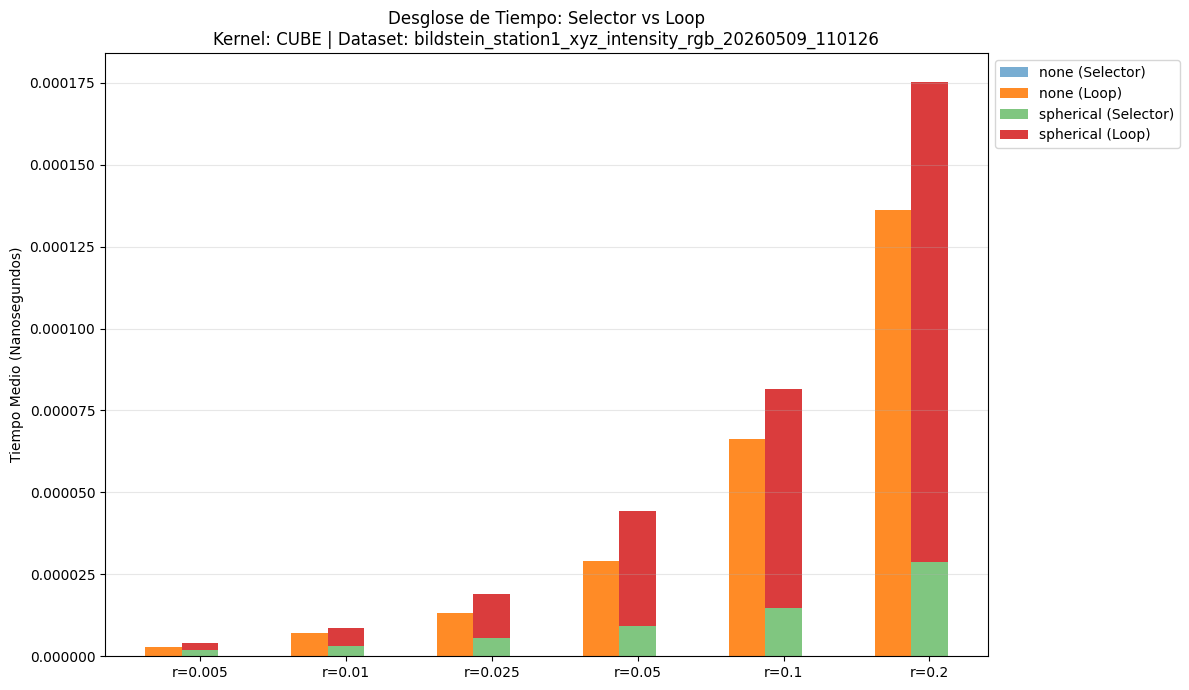

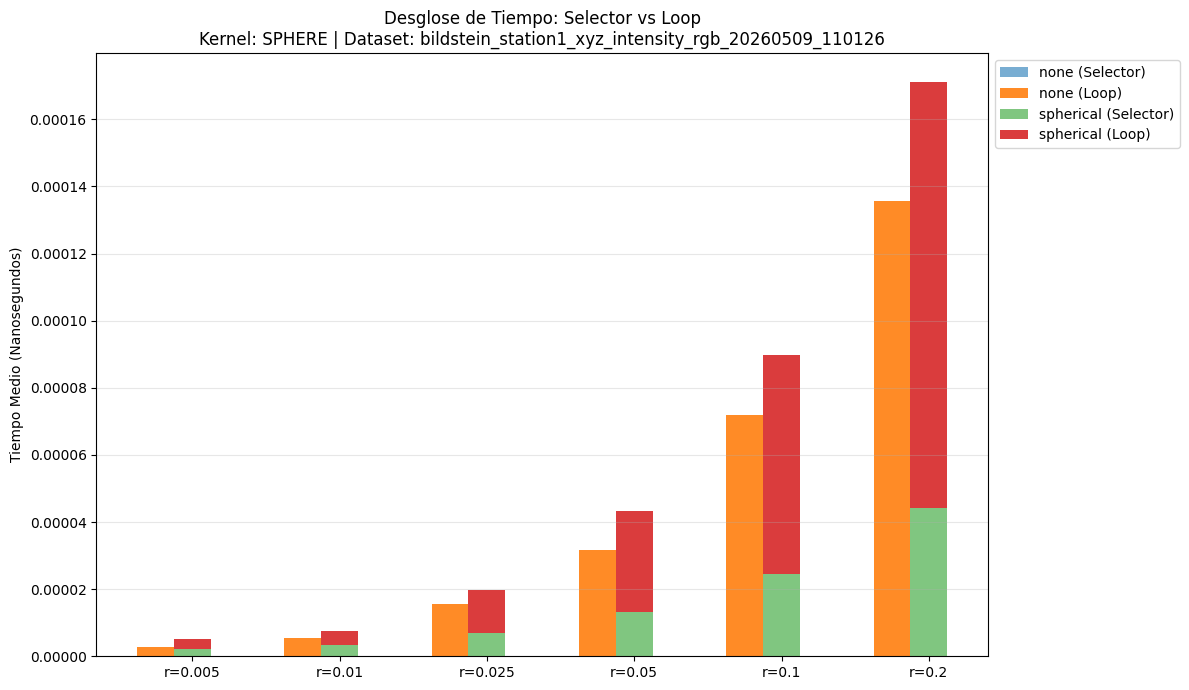

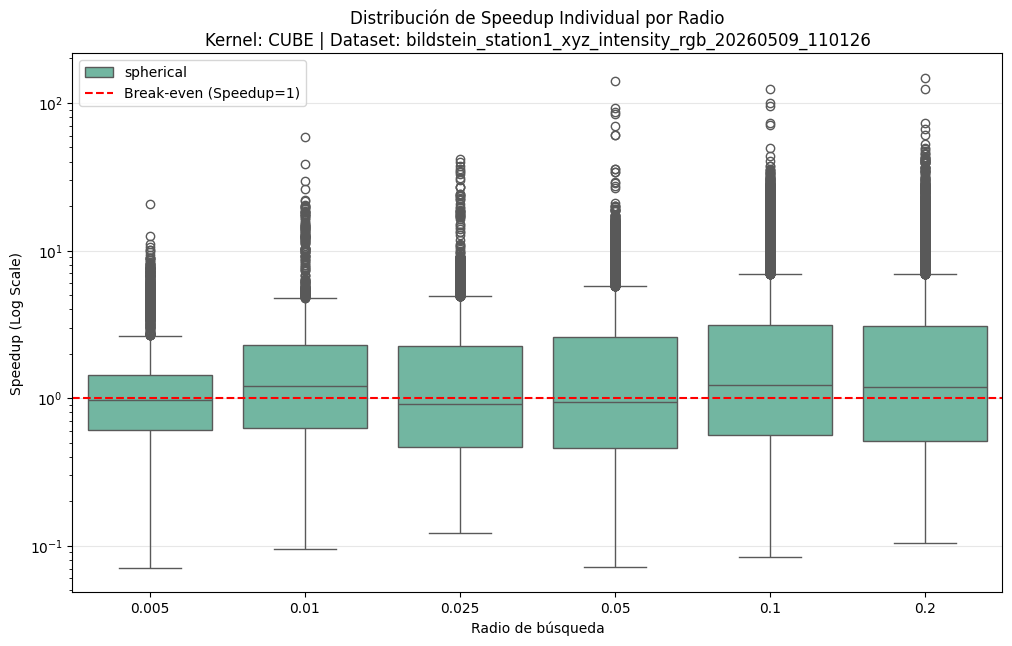

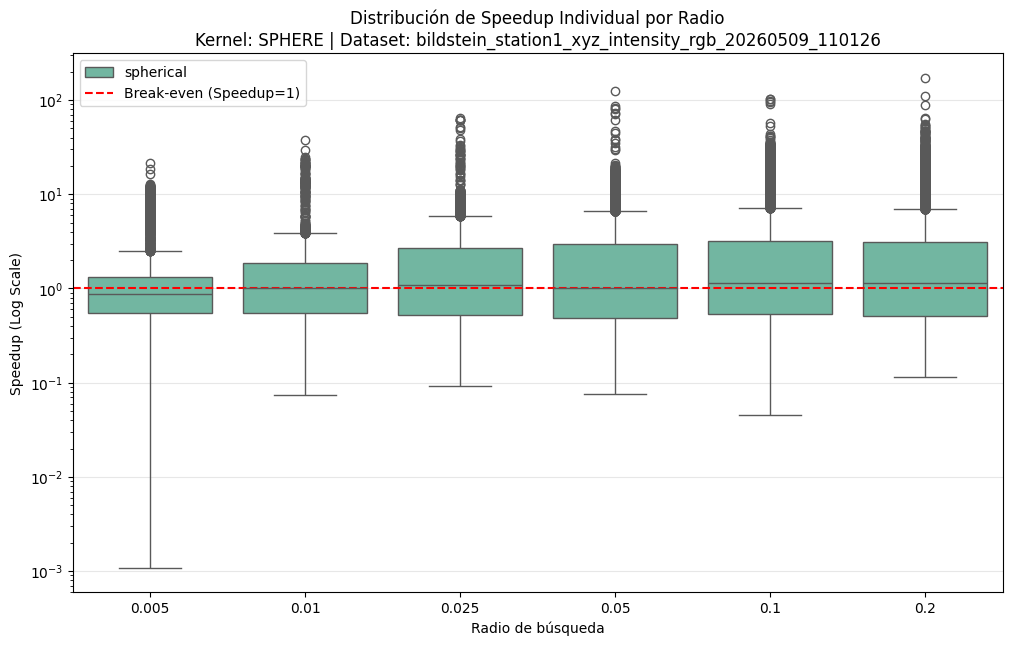

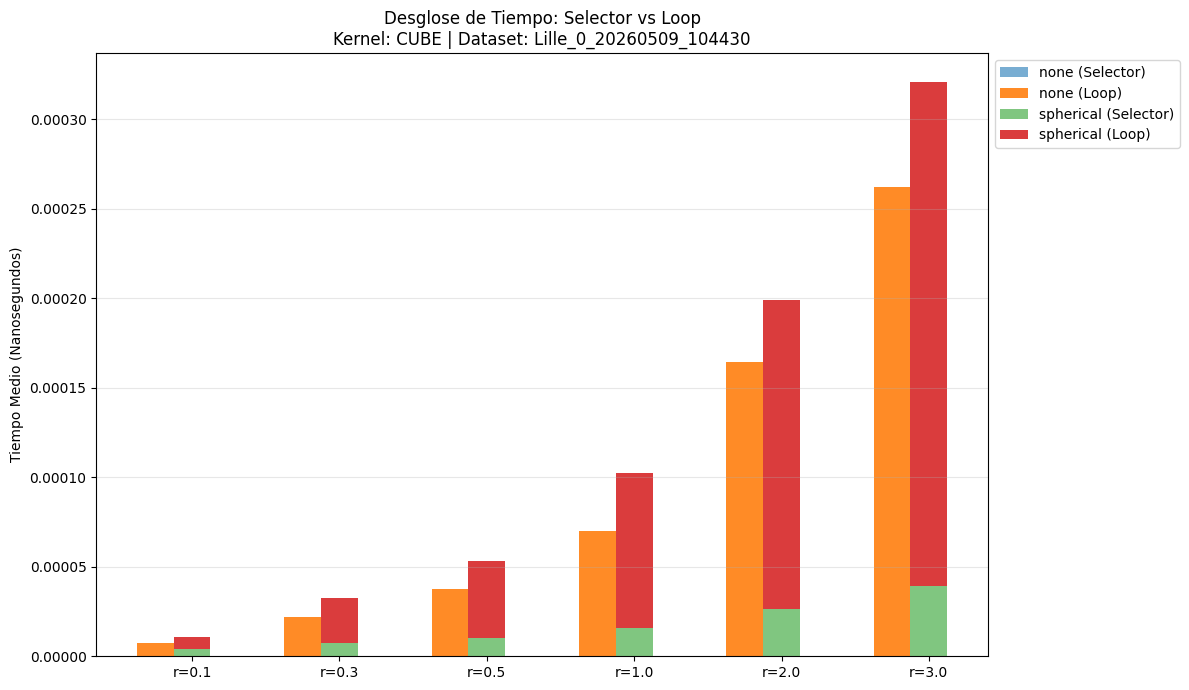

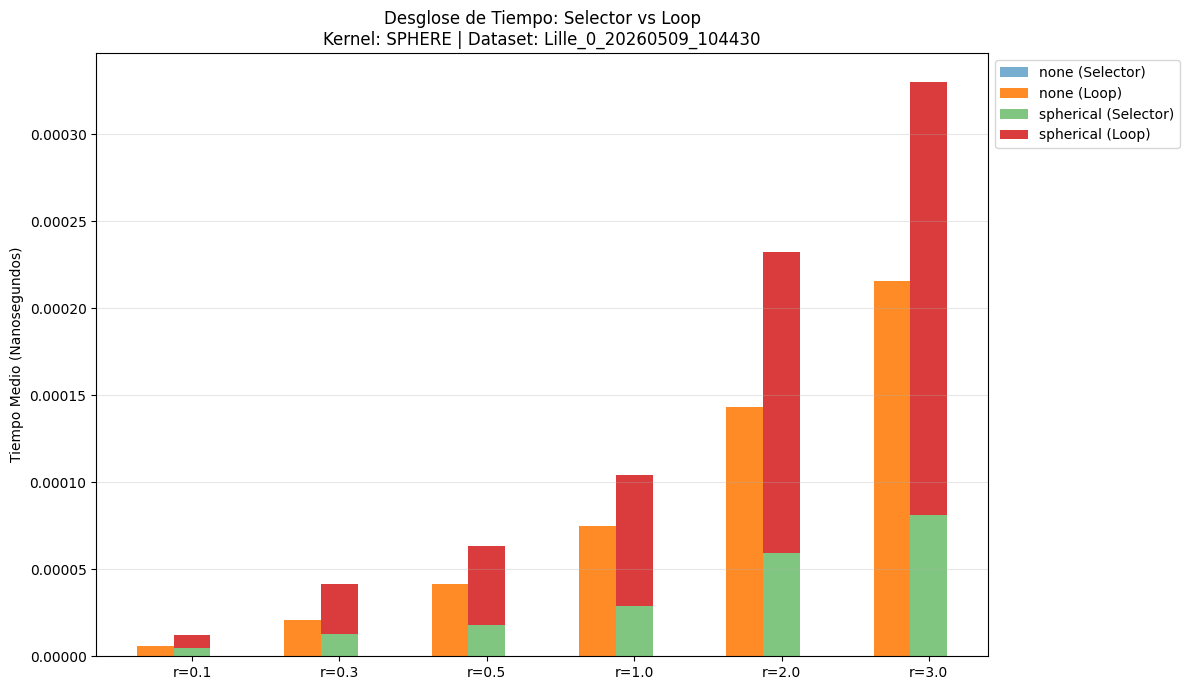

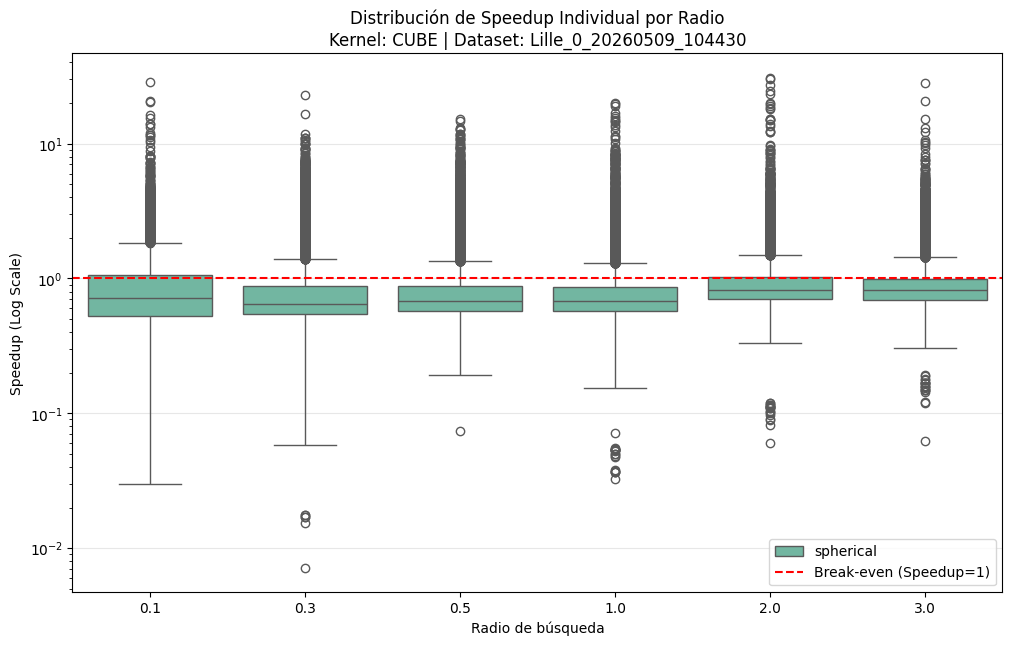

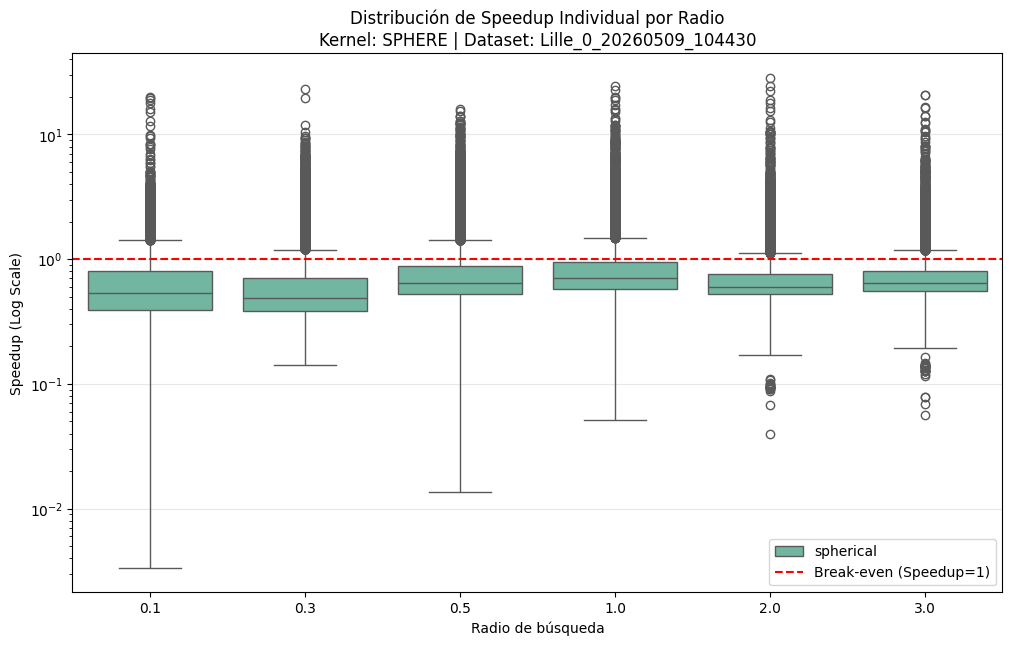

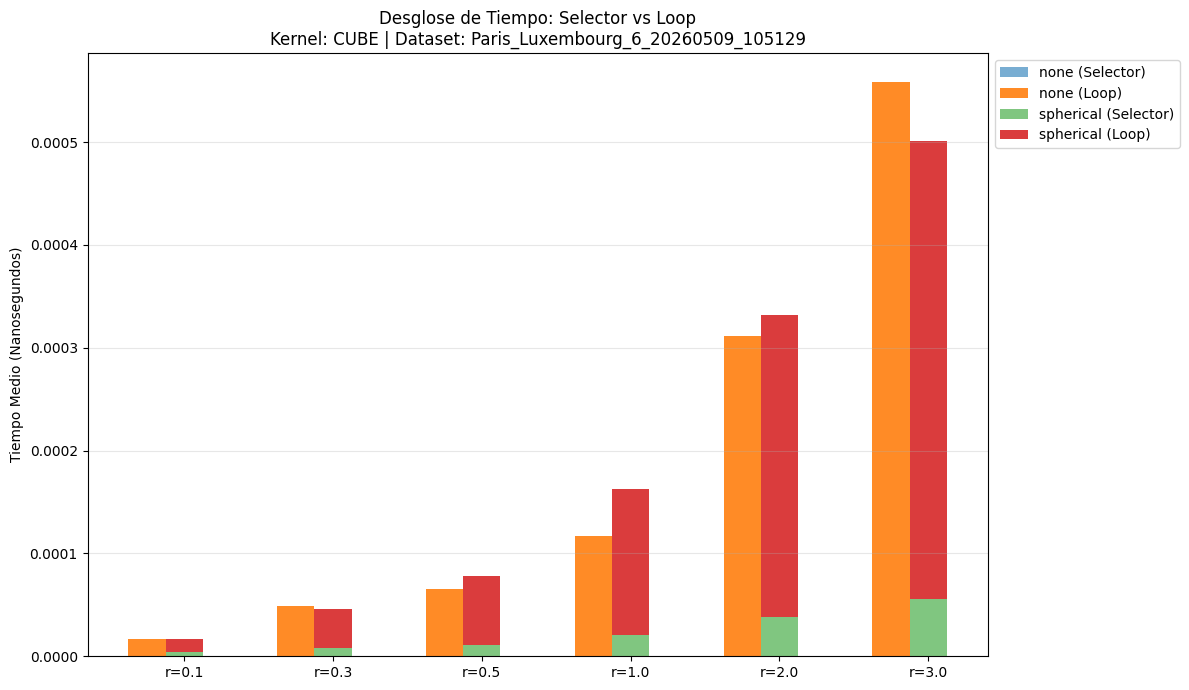

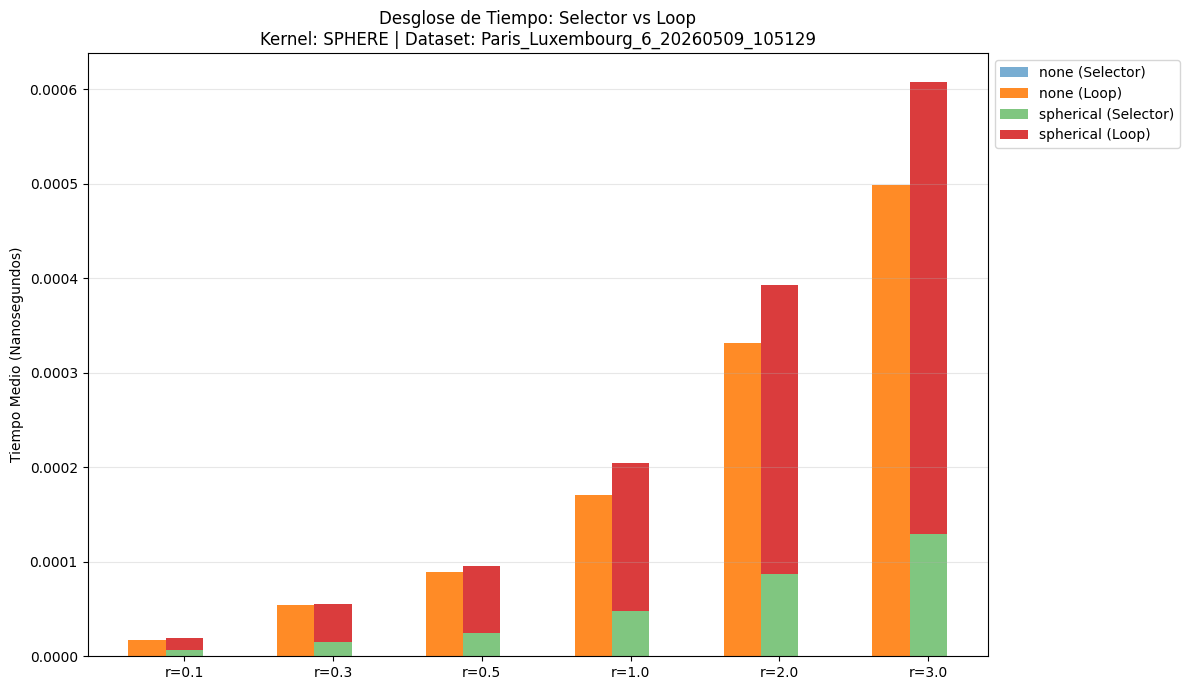

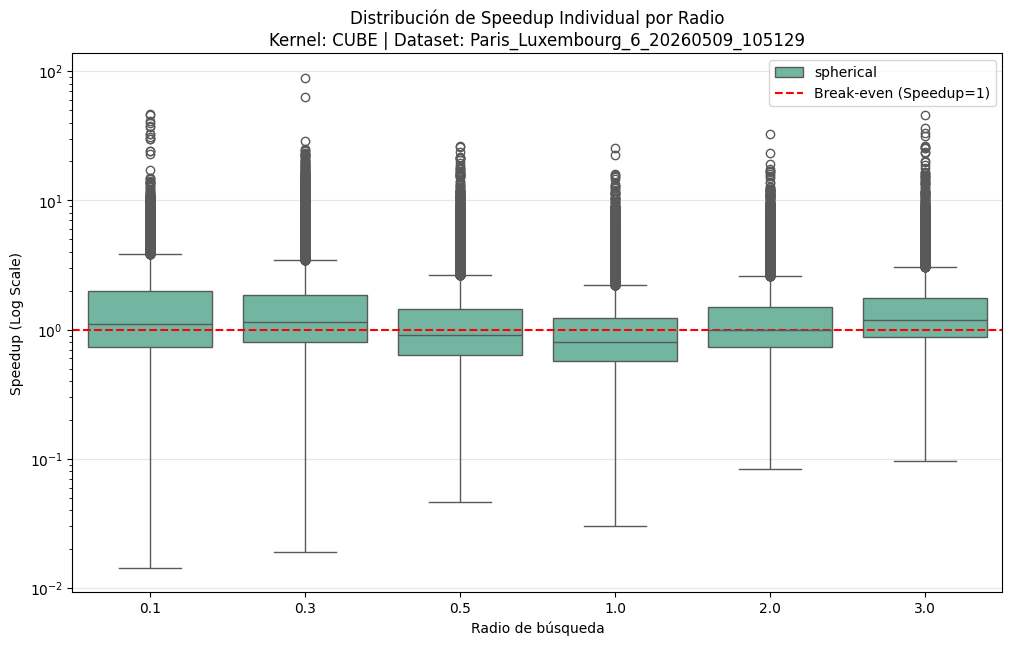

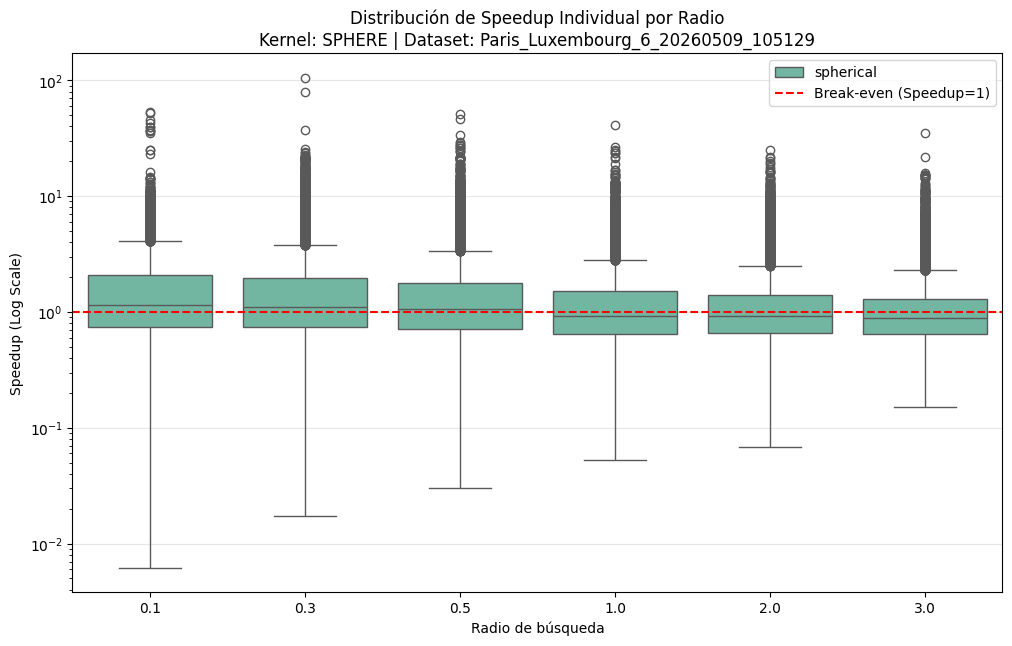

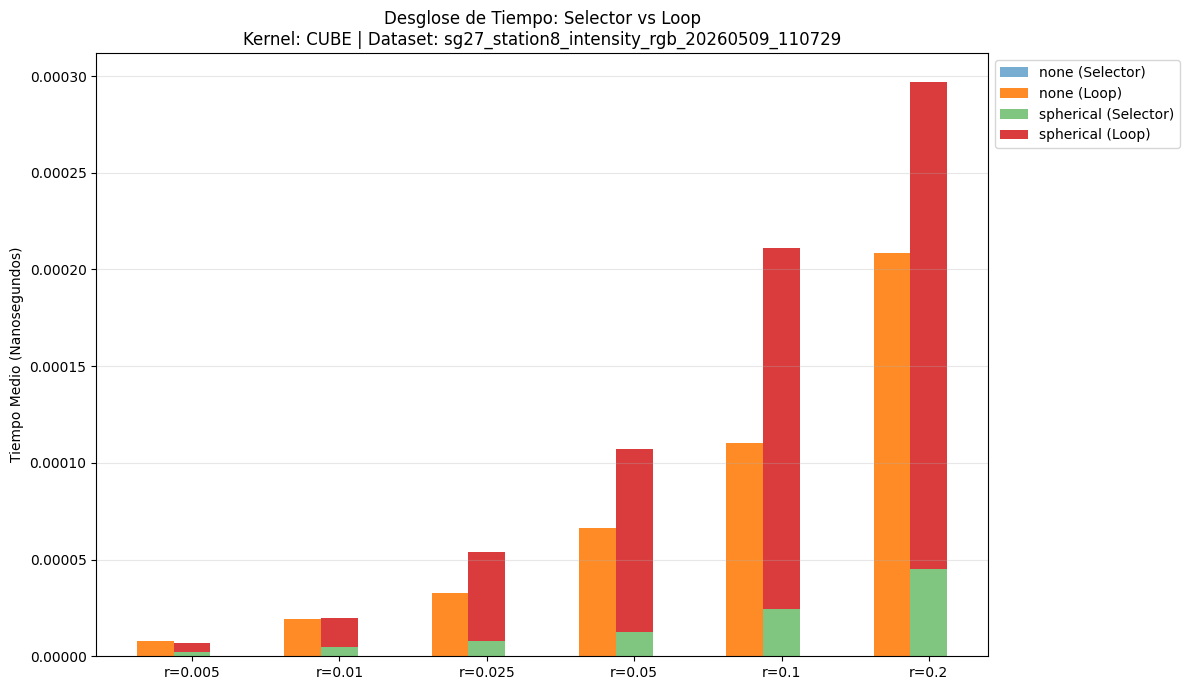

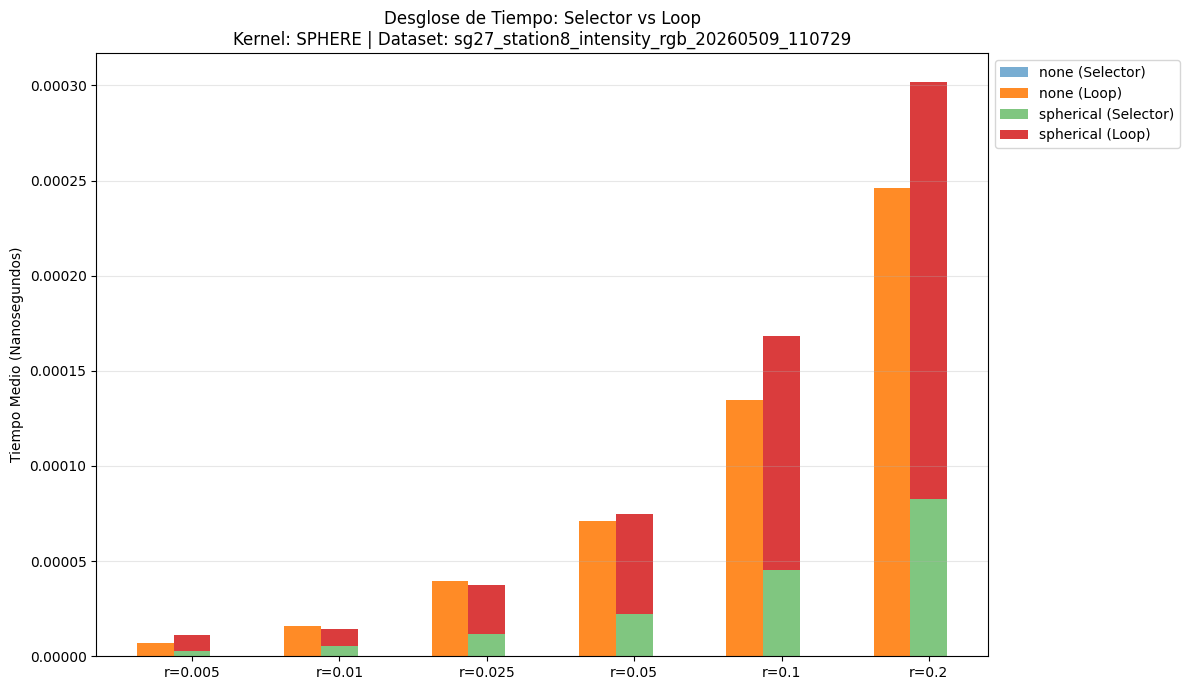

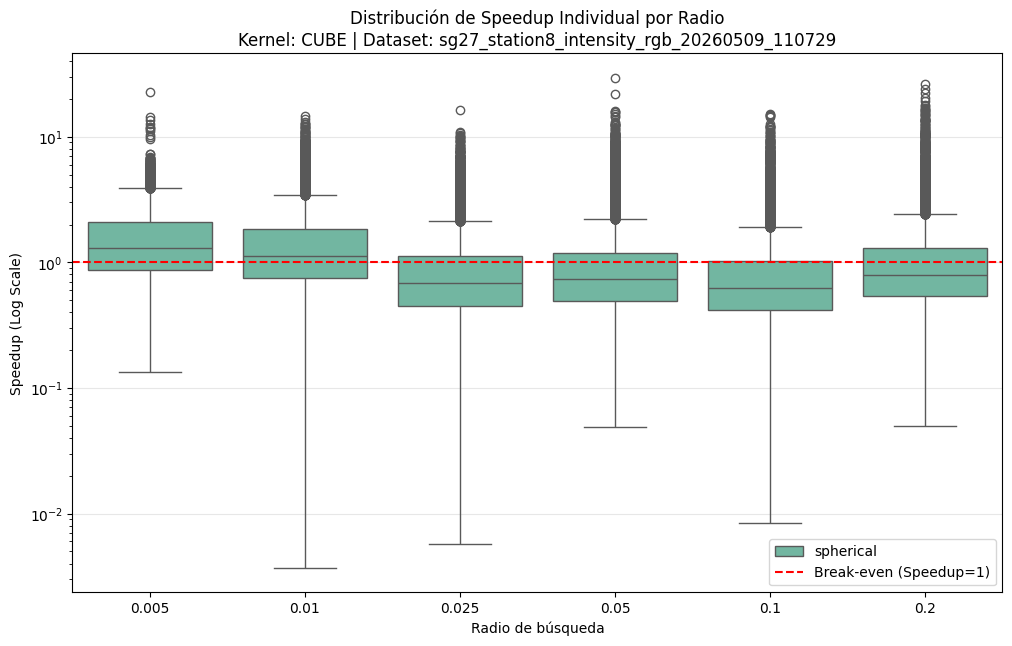

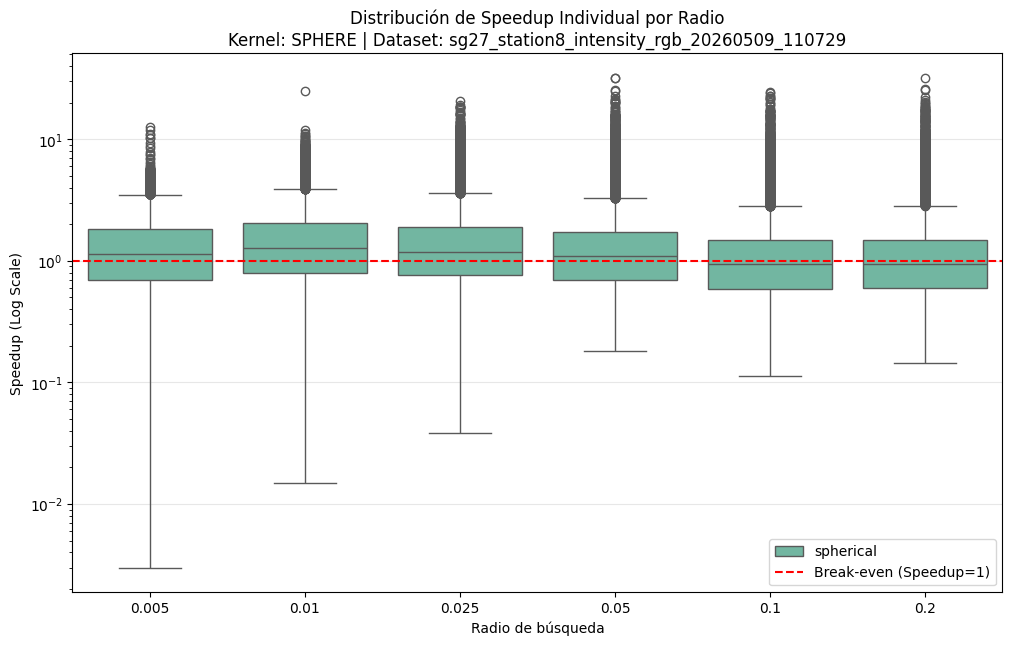

In [9]:
if cesga:
    for log in Path('../outv2.3-leaves').glob('*.csv'):
        analyze_speedup_and_timing(log, save=False)